# Phase 6 — VIX Baseline and Detector Robustness

This notebook compares the frozen factor-specific excess-kurtosis detector with
a naive VIX-based market-stress baseline.

The primary detector remains unchanged:

- rolling excess kurtosis,
- 63-trading-day diagnostic window,
- 252-observation causal standardization window,
- warning threshold of 2.0,
- five-day warning reset period,
- 126-trading-day warning-to-collapse horizon.

Because VIX has a shorter history than the factor datasets, both detectors are
evaluated over a common VIX-available sample. Full-sample results from Notebook
4 remain the primary holdout results.

This notebook also performs sensitivity analysis using approximately ±20%
changes to the frozen diagnostic window and warning threshold. These variants
are exploratory robustness checks and do not replace the frozen specification.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"

FACTOR_INPUT = (
    PROCESSED / "factor_returns_daily.parquet"
)

VIX_INPUT = (
    PROCESSED / "vix_daily.parquet"
)

COLLAPSE_EVENTS_INPUT = (
    RESULTS / "collapse_events.csv"
)

HOLDOUT_EVENTS_INPUT = (
    RESULTS / "holdout_event_results.csv"
)

HOLDOUT_WARNINGS_INPUT = (
    RESULTS / "holdout_warning_results.csv"
)

FROZEN_CONFIG_INPUT = (
    RESULTS / "frozen_diagnostic_parameters.json"
)

print("Factor data:", FACTOR_INPUT)
print("VIX data:", VIX_INPUT)
print("Collapse events:", COLLAPSE_EVENTS_INPUT)
print("Frozen parameters:", FROZEN_CONFIG_INPUT)

Mounted at /content/drive
Factor data: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/processed/factor_returns_daily.parquet
VIX data: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/processed/vix_daily.parquet
Collapse events: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_events.csv
Frozen parameters: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/frozen_diagnostic_parameters.json


In [2]:
factors = pd.read_parquet(
    FACTOR_INPUT
)

vix = pd.read_parquet(
    VIX_INPUT
)

collapse_events = pd.read_csv(
    COLLAPSE_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

primary_event_results = pd.read_csv(
    HOLDOUT_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
        "warning_window_start",
        "matched_warning_date",
    ],
)

primary_warning_results = pd.read_csv(
    HOLDOUT_WARNINGS_INPUT,
    parse_dates=["warning_date"],
)

with open(
    FROZEN_CONFIG_INPUT,
    "r",
    encoding="utf-8",
) as file:
    frozen_config = json.load(file)

print("Factor shape:", factors.shape)
print("VIX shape:", vix.shape)
print("Frozen status:", frozen_config["status"])

Factor shape: (15833, 7)
VIX shape: (9240, 1)
Frozen status: FROZEN


In [3]:
FACTOR_COLUMNS = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM",
]

DIAGNOSTIC_WINDOW = int(
    frozen_config["diagnostic_window"]
)

ZSCORE_REFERENCE_WINDOW = int(
    frozen_config["zscore_reference_window"]
)

WARNING_THRESHOLD = float(
    frozen_config["warning_threshold"]
)

WARNING_RESET_DAYS = int(
    frozen_config["warning_reset_days"]
)

WARNING_HORIZON = int(
    frozen_config[
        "warning_to_collapse_horizon_days"
    ]
)

DEVELOPMENT_FACTOR = frozen_config[
    "factor_used_for_development"
]

DEVELOPMENT_COLLAPSE_START = pd.Timestamp(
    frozen_config["development_collapse_start"]
)

assert frozen_config["status"] == "FROZEN"
assert frozen_config["selected_diagnostics"] == [
    "excess_kurtosis"
]

assert isinstance(factors.index, pd.DatetimeIndex)
assert factors.index.is_unique
assert factors.index.is_monotonic_increasing

assert isinstance(vix.index, pd.DatetimeIndex)
assert vix.index.is_unique
assert vix.index.is_monotonic_increasing

assert "VIX" in vix.columns
assert set(FACTOR_COLUMNS).issubset(factors.columns)

print("✓ Inputs and frozen parameters passed validation")

✓ Inputs and frozen parameters passed validation


In [4]:
development_event_mask = (
    (
        collapse_events["factor"]
        == DEVELOPMENT_FACTOR
    )
    & (
        collapse_events["collapse_start"]
        == DEVELOPMENT_COLLAPSE_START
    )
)

assert development_event_mask.sum() == 1

holdout_events = (
    collapse_events.loc[
        ~development_event_mask
    ]
    .copy()
    .sort_values(
        [
            "factor",
            "collapse_start",
        ]
    )
    .reset_index(drop=True)
)

print("Holdout events:", len(holdout_events))

Holdout events: 86


In [5]:
VIX_BASELINE_REFERENCE_WINDOW = 252
VIX_BASELINE_THRESHOLD = 2.0

vix_first_observation = (
    vix["VIX"].first_valid_index()
)

common_index = (
    factors.index
    .intersection(vix.index)
    .sort_values()
)

assert len(common_index) > 0

COMMON_SAMPLE_START = common_index.min()
COMMON_SAMPLE_END = common_index.max()

print("Common raw sample:")
print(COMMON_SAMPLE_START.date(), "to", COMMON_SAMPLE_END.date())

Common raw sample:
1990-01-02 to 2026-05-29


In [6]:
def rolling_excess_kurtosis(
    returns: pd.Series,
    window: int,
) -> pd.Series:
    """
    Calculate trailing Fisher excess kurtosis.
    """
    return returns.rolling(
        window=window,
        min_periods=window,
    ).kurt()
def historical_zscore(
    statistic: pd.Series,
    reference_window: int,
) -> pd.Series:
    """
    Standardize using values dated t-1 and earlier.
    """
    prior_statistic = statistic.shift(1)

    reference_mean = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).mean()

    reference_std = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).std(ddof=1)

    zscore = (
        statistic - reference_mean
    ) / reference_std

    return zscore.replace(
        [np.inf, -np.inf],
        np.nan,
    )
def compute_kurtosis_fragility_score(
    returns: pd.Series,
    diagnostic_window: int,
    reference_window: int,
) -> pd.Series:
    """
    Compute the causal excess-kurtosis fragility score.
    """
    raw_kurtosis = rolling_excess_kurtosis(
        returns,
        diagnostic_window,
    )

    score = historical_zscore(
        raw_kurtosis,
        reference_window,
    )

    score.name = "excess_kurtosis_fragility"

    return score

In [7]:
def compute_vix_baseline_score(
    vix_level: pd.Series,
    reference_window: int,
) -> pd.Series:
    """
    Compute a causal historical z-score of the VIX closing level.

    At date t, the benchmark uses VIX observations through t-1.
    """
    score = historical_zscore(
        vix_level,
        reference_window=reference_window,
    )

    score.name = "vix_level_zscore"

    return score
vix_baseline_score = compute_vix_baseline_score(
    vix["VIX"],
    reference_window=VIX_BASELINE_REFERENCE_WINDOW,
)

VIX_USABLE_START = (
    vix_baseline_score.first_valid_index()
)

assert VIX_USABLE_START is not None

COMMON_EVALUATION_START = max(
    COMMON_SAMPLE_START,
    VIX_USABLE_START,
)

COMMON_EVALUATION_END = COMMON_SAMPLE_END

print(
    "Common evaluation sample:",
    COMMON_EVALUATION_START.date(),
    "to",
    COMMON_EVALUATION_END.date(),
)

Common evaluation sample: 1990-12-31 to 2026-05-29


In [8]:
def extract_warning_events(
    warning_condition: pd.Series,
    reset_days: int,
) -> pd.DatetimeIndex:
    """
    Extract distinct warning starts.

    A new warning requires at least `reset_days` consecutive
    non-warning dates after the previous warning episode.
    """
    condition = (
        warning_condition
        .fillna(False)
        .astype(bool)
    )

    warning_dates = []
    active_warning = False
    false_run_length = reset_days

    for date, is_warning in condition.items():
        if is_warning:
            if (
                not active_warning
                and false_run_length >= reset_days
            ):
                warning_dates.append(date)

            active_warning = True
            false_run_length = 0

        else:
            if active_warning:
                false_run_length += 1

                if false_run_length >= reset_days:
                    active_warning = False
            else:
                false_run_length = min(
                    false_run_length + 1,
                    reset_days,
                )

    return pd.DatetimeIndex(warning_dates)

In [9]:
frozen_fragility_scores = pd.DataFrame(
    {
        factor: compute_kurtosis_fragility_score(
            factors[factor],
            diagnostic_window=DIAGNOSTIC_WINDOW,
            reference_window=ZSCORE_REFERENCE_WINDOW,
        )
        for factor in FACTOR_COLUMNS
    },
    index=factors.index,
)

frozen_warning_dates_by_factor = {}

for factor in FACTOR_COLUMNS:
    warning_dates = extract_warning_events(
        frozen_fragility_scores[factor]
        >= WARNING_THRESHOLD,
        reset_days=WARNING_RESET_DAYS,
    )

    frozen_warning_dates_by_factor[
        factor
    ] = warning_dates[
        (
            warning_dates
            >= COMMON_EVALUATION_START
        )
        & (
            warning_dates
            <= COMMON_EVALUATION_END
        )
    ]

In [10]:
vix_warning_dates = extract_warning_events(
    vix_baseline_score >= VIX_BASELINE_THRESHOLD,
    reset_days=WARNING_RESET_DAYS,
)

vix_warning_dates = vix_warning_dates[
    (
        vix_warning_dates
        >= COMMON_EVALUATION_START
    )
    & (
        vix_warning_dates
        <= COMMON_EVALUATION_END
    )
]

vix_warning_dates_by_factor = {
    factor: vix_warning_dates.copy()
    for factor in FACTOR_COLUMNS
}

print("Distinct VIX warning dates:", len(vix_warning_dates))

Distinct VIX warning dates: 90


In [11]:
common_holdout_events = (
    holdout_events.loc[
        (
            holdout_events["collapse_start"]
            >= COMMON_EVALUATION_START
        )
        & (
            holdout_events["collapse_start"]
            <= COMMON_EVALUATION_END
        )
    ]
    .copy()
    .sort_values(
        [
            "factor",
            "collapse_start",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Common-sample holdout events:",
    len(common_holdout_events),
)

display(
    common_holdout_events.groupby(
        "factor"
    ).size().rename(
        "event_count"
    ).reindex(
        FACTOR_COLUMNS,
        fill_value=0,
    )
)

Common-sample holdout events: 55


,event_count
factor,
MKT_RF,7
SMB,11
HML,6
RMW,12
CMA,10
MOM,9


In [12]:
def match_warnings_to_events(
    factor: str,
    factor_index: pd.DatetimeIndex,
    warning_dates: pd.DatetimeIndex,
    factor_events: pd.DataFrame,
    warning_horizon: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Match the earliest unmatched warning in each event's
    pre-collapse horizon.

    Each warning and each collapse may be matched at most once.
    """
    warning_dates = pd.DatetimeIndex(
        sorted(
            pd.DatetimeIndex(
                warning_dates
            ).unique()
        )
    )

    factor_events = (
        factor_events
        .sort_values("collapse_start")
        .reset_index(drop=True)
    )

    used_warning_dates = set()
    event_records = []

    for event in factor_events.itertuples(
        index=False
    ):
        collapse_start = pd.Timestamp(
            event.collapse_start
        )

        collapse_position = (
            factor_index.get_indexer(
                [collapse_start]
            )[0]
        )

        if collapse_position == -1:
            raise ValueError(
                f"{factor}: collapse date "
                f"{collapse_start.date()} "
                "not found in index."
            )

        window_start_position = max(
            0,
            collapse_position
            - warning_horizon,
        )

        window_start = factor_index[
            window_start_position
        ]

        eligible_warnings = [
            warning_date
            for warning_date in warning_dates
            if (
                window_start
                <= warning_date
                < collapse_start
            )
            and warning_date
            not in used_warning_dates
        ]

        if eligible_warnings:
            matched_warning = min(
                eligible_warnings
            )

            warning_position = (
                factor_index.get_indexer(
                    [matched_warning]
                )[0]
            )

            lead_time = (
                collapse_position
                - warning_position
            )

            detected = True
            used_warning_dates.add(
                matched_warning
            )
        else:
            matched_warning = pd.NaT
            lead_time = np.nan
            detected = False

        event_records.append(
            {
                "factor": factor,
                "collapse_start":
                    collapse_start,
                "collapse_end":
                    pd.Timestamp(
                        event.collapse_end
                    ),
                "detected":
                    detected,
                "matched_warning_date":
                    matched_warning,
                "lead_time_days":
                    lead_time,
            }
        )

    warning_records = [
        {
            "factor": factor,
            "warning_date": warning_date,
            "classification": (
                "true_positive"
                if warning_date
                in used_warning_dates
                else "false_positive"
            ),
        }
        for warning_date in warning_dates
    ]

    return (
        pd.DataFrame(event_records),
        pd.DataFrame(warning_records),
    )

In [13]:
def evaluate_detector(
    detector_name: str,
    warning_dates_by_factor: dict,
    factor_events: pd.DataFrame,
    factor_index: pd.DatetimeIndex,
    warning_horizon: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Evaluate one detector across all factors.
    """
    event_outputs = []
    warning_outputs = []

    for factor in FACTOR_COLUMNS:
        event_result, warning_result = (
            match_warnings_to_events(
                factor=factor,
                factor_index=factor_index,
                warning_dates=(
                    warning_dates_by_factor[
                        factor
                    ]
                ),
                factor_events=(
                    factor_events.loc[
                        factor_events["factor"]
                        == factor
                    ]
                ),
                warning_horizon=warning_horizon,
            )
        )

        event_outputs.append(
            event_result
        )

        warning_outputs.append(
            warning_result
        )

    event_results = pd.concat(
        event_outputs,
        ignore_index=True,
    )

    warning_results = pd.concat(
        warning_outputs,
        ignore_index=True,
    )

    total_events = len(event_results)
    detected_events = int(
        event_results["detected"].sum()
    )

    total_warnings = len(warning_results)
    true_positive_warnings = int(
        warning_results[
            "classification"
        ].eq("true_positive").sum()
    )

    lead_times = (
        event_results.loc[
            event_results["detected"],
            "lead_time_days",
        ]
        .dropna()
        .astype(float)
    )

    metrics = pd.DataFrame(
        [
            {
                "detector": detector_name,
                "collapse_events":
                    total_events,
                "detected_events":
                    detected_events,
                "missed_events":
                    total_events
                    - detected_events,
                "warning_events":
                    total_warnings,
                "true_positive_warnings":
                    true_positive_warnings,
                "false_positive_warnings":
                    total_warnings
                    - true_positive_warnings,
                "recall": (
                    detected_events
                    / total_events
                    if total_events
                    else np.nan
                ),
                "precision": (
                    true_positive_warnings
                    / total_warnings
                    if total_warnings
                    else np.nan
                ),
                "false_positive_rate": (
                    (
                        total_warnings
                        - true_positive_warnings
                    )
                    / total_warnings
                    if total_warnings
                    else np.nan
                ),
                "median_lead_time_days":
                    lead_times.median(),
                "mean_lead_time_days":
                    lead_times.mean(),
            }
        ]
    )

    return (
        event_results,
        warning_results,
        metrics,
    )

In [14]:
(
    common_frozen_event_results,
    common_frozen_warning_results,
    common_frozen_metrics,
) = evaluate_detector(
    detector_name="frozen_excess_kurtosis",
    warning_dates_by_factor=(
        frozen_warning_dates_by_factor
    ),
    factor_events=common_holdout_events,
    factor_index=factors.index,
    warning_horizon=WARNING_HORIZON,
)

(
    vix_event_results,
    vix_warning_results,
    vix_metrics,
) = evaluate_detector(
    detector_name="vix_level_zscore",
    warning_dates_by_factor=(
        vix_warning_dates_by_factor
    ),
    factor_events=common_holdout_events,
    factor_index=factors.index,
    warning_horizon=WARNING_HORIZON,
)

baseline_comparison = pd.concat(
    [
        common_frozen_metrics,
        vix_metrics,
    ],
    ignore_index=True,
)

baseline_comparison

,detector,collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,recall,precision,false_positive_rate,median_lead_time_days,mean_lead_time_days
0,frozen_excess_kurtosis,55,31,24,298,31,267,0.563636,0.104027,0.895973,83.0,73.225806
1,vix_level_zscore,55,35,20,540,35,505,0.636364,0.064815,0.935185,103.0,88.142857


In [15]:
vix_matched_dates = pd.DatetimeIndex(
    vix_event_results[
        "matched_warning_date"
    ]
    .dropna()
    .unique()
)

vix_unique_warning_summary = pd.DataFrame(
    [
        {
            "unique_vix_warning_dates":
                len(vix_warning_dates),
            "unique_vix_warning_dates_matched_to_any_factor":
                len(vix_matched_dates),
            "unique_date_any_factor_precision":
                (
                    len(vix_matched_dates)
                    / len(vix_warning_dates)
                    if len(vix_warning_dates)
                    else np.nan
                ),
        }
    ]
)

vix_unique_warning_summary

,unique_vix_warning_dates,unique_vix_warning_dates_matched_to_any_factor,unique_date_any_factor_precision
0,90,28,0.311111


In [16]:
def build_factor_metrics(
    detector_name: str,
    event_results: pd.DataFrame,
    warning_results: pd.DataFrame,
) -> pd.DataFrame:
    records = []

    for factor in FACTOR_COLUMNS:
        factor_events = event_results.loc[
            event_results["factor"]
            == factor
        ]

        factor_warnings = warning_results.loc[
            warning_results["factor"]
            == factor
        ]

        total_events = len(factor_events)

        detected_events = int(
            factor_events["detected"].sum()
        )

        total_warnings = len(
            factor_warnings
        )

        true_positive_warnings = int(
            factor_warnings[
                "classification"
            ].eq("true_positive").sum()
        )

        lead_times = (
            factor_events.loc[
                factor_events["detected"],
                "lead_time_days",
            ]
            .dropna()
        )

        records.append(
            {
                "detector":
                    detector_name,
                "factor":
                    factor,
                "collapse_events":
                    total_events,
                "detected_events":
                    detected_events,
                "warning_events":
                    total_warnings,
                "recall": (
                    detected_events
                    / total_events
                    if total_events
                    else np.nan
                ),
                "precision": (
                    true_positive_warnings
                    / total_warnings
                    if total_warnings
                    else np.nan
                ),
                "median_lead_time_days":
                    lead_times.median(),
            }
        )

    return pd.DataFrame(records)

In [17]:
factor_baseline_comparison = pd.concat(
    [
        build_factor_metrics(
            "frozen_excess_kurtosis",
            common_frozen_event_results,
            common_frozen_warning_results,
        ),
        build_factor_metrics(
            "vix_level_zscore",
            vix_event_results,
            vix_warning_results,
        ),
    ],
    ignore_index=True,
)

factor_baseline_comparison

,detector,factor,collapse_events,detected_events,warning_events,recall,precision,median_lead_time_days
0,frozen_excess_kurtosis,MKT_RF,7,3,44,0.428571,0.068182,100.0
1,frozen_excess_kurtosis,SMB,11,7,52,0.636364,0.134615,96.0
2,frozen_excess_kurtosis,HML,6,2,51,0.333333,0.039216,75.5
3,frozen_excess_kurtosis,RMW,12,8,57,0.666667,0.140351,51.0
4,frozen_excess_kurtosis,CMA,10,4,41,0.400000,0.097561,78.5
5,frozen_excess_kurtosis,MOM,9,7,53,0.777778,0.132075,83.0
6,vix_level_zscore,MKT_RF,7,7,90,1.000000,0.077778,112.0
7,vix_level_zscore,SMB,11,10,90,0.909091,0.111111,95.0
8,vix_level_zscore,HML,6,3,90,0.500000,0.033333,93.0
9,vix_level_zscore,RMW,12,6,90,0.500000,0.066667,110.0


In [18]:
event_detector_comparison = (
    common_frozen_event_results[
        [
            "factor",
            "collapse_start",
            "detected",
            "lead_time_days",
        ]
    ]
    .rename(
        columns={
            "detected":
                "kurtosis_detected",
            "lead_time_days":
                "kurtosis_lead_time_days",
        }
    )
    .merge(
        vix_event_results[
            [
                "factor",
                "collapse_start",
                "detected",
                "lead_time_days",
            ]
        ].rename(
            columns={
                "detected":
                    "vix_detected",
                "lead_time_days":
                    "vix_lead_time_days",
            }
        ),
        on=[
            "factor",
            "collapse_start",
        ],
        how="inner",
        validate="one_to_one",
    )
)

def classify_detector_overlap(
    row: pd.Series,
) -> str:
    if (
        row["kurtosis_detected"]
        and row["vix_detected"]
    ):
        return "both"

    if row["kurtosis_detected"]:
        return "kurtosis_only"

    if row["vix_detected"]:
        return "vix_only"

    return "neither"

event_detector_comparison[
    "detection_overlap"
] = event_detector_comparison.apply(
    classify_detector_overlap,
    axis=1,
)

overlap_summary = (
    event_detector_comparison[
        "detection_overlap"
    ]
    .value_counts()
    .reindex(
        [
            "both",
            "kurtosis_only",
            "vix_only",
            "neither",
        ],
        fill_value=0,
    )
    .rename_axis(
        "classification"
    )
    .reset_index(
        name="event_count"
    )
)

overlap_summary

,classification,event_count
0,both,20
1,kurtosis_only,11
2,vix_only,15
3,neither,9


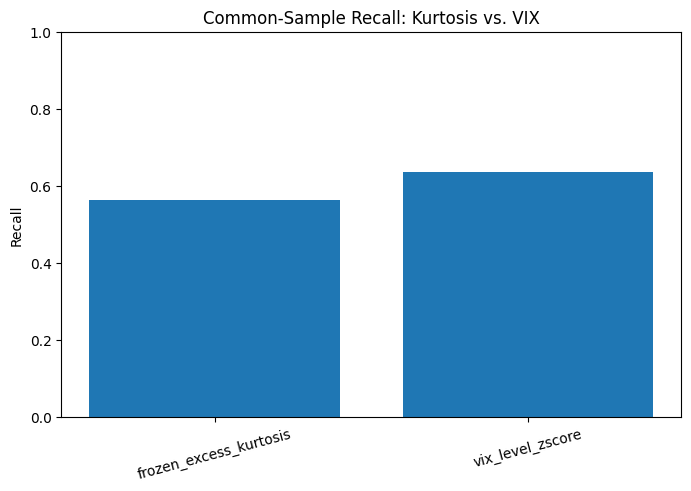

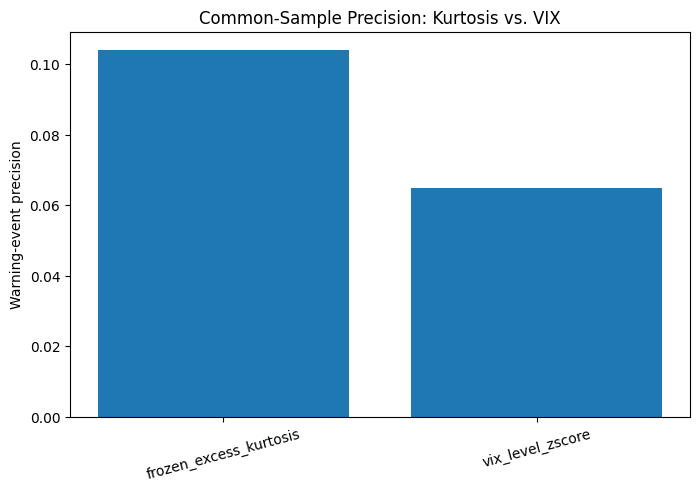

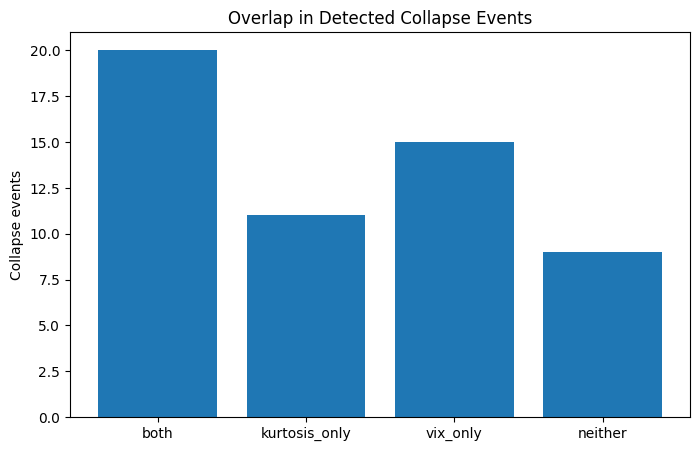

In [19]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    baseline_comparison["detector"],
    baseline_comparison["recall"],
)

ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title(
    "Common-Sample Recall: Kurtosis vs. VIX"
)

plt.xticks(rotation=15)
plt.show()

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    baseline_comparison["detector"],
    baseline_comparison["precision"],
)

ax.set_ylabel("Warning-event precision")
ax.set_title(
    "Common-Sample Precision: Kurtosis vs. VIX"
)

plt.xticks(rotation=15)
plt.show()

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    overlap_summary["classification"],
    overlap_summary["event_count"],
)

ax.set_ylabel("Collapse events")
ax.set_title(
    "Overlap in Detected Collapse Events"
)

plt.show()

In [20]:
test_vix = vix["VIX"].copy()

cutoff_position = int(
    len(test_vix) * 0.75
)

cutoff_date = test_vix.index[
    cutoff_position
]

altered_vix = test_vix.copy()

altered_vix.loc[
    altered_vix.index > cutoff_date
] = (
    altered_vix.loc[
        altered_vix.index > cutoff_date
    ]
    * 3
    + 50
)

original_vix_score = (
    compute_vix_baseline_score(
        test_vix,
        reference_window=(
            VIX_BASELINE_REFERENCE_WINDOW
        ),
    )
)

altered_vix_score = (
    compute_vix_baseline_score(
        altered_vix,
        reference_window=(
            VIX_BASELINE_REFERENCE_WINDOW
        ),
    )
)

pd.testing.assert_series_equal(
    original_vix_score.loc[:cutoff_date],
    altered_vix_score.loc[:cutoff_date],
)

print(
    "✓ Future VIX alterations did not "
    "change earlier baseline scores"
)

✓ Future VIX alterations did not change earlier baseline scores


In [21]:
SENSITIVITY_WINDOWS = [
    50,
    63,
    76,
]

SENSITIVITY_THRESHOLDS = [
    1.6,
    2.0,
    2.4,
]

assert DIAGNOSTIC_WINDOW in (
    SENSITIVITY_WINDOWS
)

assert WARNING_THRESHOLD in (
    SENSITIVITY_THRESHOLDS
)

In [22]:
sensitivity_records = []

for diagnostic_window in (
    SENSITIVITY_WINDOWS
):
    sensitivity_scores = pd.DataFrame(
        {
            factor:
                compute_kurtosis_fragility_score(
                    factors[factor],
                    diagnostic_window=(
                        diagnostic_window
                    ),
                    reference_window=(
                        ZSCORE_REFERENCE_WINDOW
                    ),
                )
            for factor in FACTOR_COLUMNS
        },
        index=factors.index,
    )

    for threshold in (
        SENSITIVITY_THRESHOLDS
    ):
        warning_dates_by_factor = {}

        for factor in FACTOR_COLUMNS:
            warning_dates = (
                extract_warning_events(
                    sensitivity_scores[factor]
                    >= threshold,
                    reset_days=(
                        WARNING_RESET_DAYS
                    ),
                )
            )

            warning_dates_by_factor[
                factor
            ] = warning_dates[
                (
                    warning_dates
                    >= COMMON_EVALUATION_START
                )
                & (
                    warning_dates
                    <= COMMON_EVALUATION_END
                )
            ]

        (
            sensitivity_event_results,
            sensitivity_warning_results,
            sensitivity_metrics,
        ) = evaluate_detector(
            detector_name=(
                f"kurtosis_w{diagnostic_window}"
                f"_t{threshold}"
            ),
            warning_dates_by_factor=(
                warning_dates_by_factor
            ),
            factor_events=(
                common_holdout_events
            ),
            factor_index=factors.index,
            warning_horizon=(
                WARNING_HORIZON
            ),
        )

        metric_row = (
            sensitivity_metrics
            .iloc[0]
            .to_dict()
        )

        metric_row[
            "diagnostic_window"
        ] = diagnostic_window

        metric_row[
            "warning_threshold"
        ] = threshold

        metric_row[
            "is_frozen_primary"
        ] = (
            diagnostic_window
            == DIAGNOSTIC_WINDOW
            and np.isclose(
                threshold,
                WARNING_THRESHOLD,
            )
        )

        sensitivity_records.append(
            metric_row
        )

sensitivity_results = pd.DataFrame(
    sensitivity_records
)

sensitivity_results = (
    sensitivity_results
    .sort_values(
        [
            "diagnostic_window",
            "warning_threshold",
        ]
    )
    .reset_index(drop=True)
)

sensitivity_results

,detector,collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,recall,precision,false_positive_rate,median_lead_time_days,mean_lead_time_days,diagnostic_window,warning_threshold,is_frozen_primary
0,kurtosis_w50_t1.6,55,36,19,385,36,349,0.654545,0.093506,0.906494,82.0,76.416667,50,1.6,False
1,kurtosis_w50_t2.0,55,31,24,339,31,308,0.563636,0.091445,0.908555,76.0,75.129032,50,2.0,False
2,kurtosis_w50_t2.4,55,27,28,276,27,249,0.490909,0.097826,0.902174,73.0,69.148148,50,2.4,False
3,kurtosis_w63_t1.6,55,36,19,338,36,302,0.654545,0.106509,0.893491,89.0,75.750000,63,1.6,False
4,kurtosis_w63_t2.0,55,31,24,298,31,267,0.563636,0.104027,0.895973,83.0,73.225806,63,2.0,True
5,kurtosis_w63_t2.4,55,27,28,237,27,210,0.490909,0.113924,0.886076,63.0,63.925926,63,2.4,False
6,kurtosis_w76_t1.6,55,32,23,317,32,285,0.581818,0.100946,0.899054,83.5,72.656250,76,1.6,False
7,kurtosis_w76_t2.0,55,30,25,280,30,250,0.545455,0.107143,0.892857,60.5,65.966667,76,2.0,False
8,kurtosis_w76_t2.4,55,25,30,217,25,192,0.454545,0.115207,0.884793,62.0,61.440000,76,2.4,False


In [23]:
primary_sensitivity_row = (
    sensitivity_results.loc[
        sensitivity_results[
            "is_frozen_primary"
        ]
    ]
)

assert len(primary_sensitivity_row) == 1

primary_sensitivity_row = (
    primary_sensitivity_row.iloc[0]
)

assert np.isclose(
    primary_sensitivity_row["recall"],
    common_frozen_metrics.loc[
        0,
        "recall",
    ],
)

assert np.isclose(
    primary_sensitivity_row["precision"],
    common_frozen_metrics.loc[
        0,
        "precision",
    ],
)

print(
    "✓ Sensitivity grid reproduces "
    "the frozen common-sample result"
)

✓ Sensitivity grid reproduces the frozen common-sample result


In [24]:
primary_recall = float(
    primary_sensitivity_row["recall"]
)

primary_precision = float(
    primary_sensitivity_row["precision"]
)

sensitivity_results[
    "recall_change_from_primary"
] = (
    sensitivity_results["recall"]
    - primary_recall
)

sensitivity_results[
    "precision_change_from_primary"
] = (
    sensitivity_results["precision"]
    - primary_precision
)

sensitivity_results[
    "relative_recall_change"
] = (
    sensitivity_results[
        "recall_change_from_primary"
    ]
    / primary_recall
    if primary_recall != 0
    else np.nan
)

sensitivity_results[
    "relative_precision_change"
] = (
    sensitivity_results[
        "precision_change_from_primary"
    ]
    / primary_precision
    if primary_precision != 0
    else np.nan
)

sensitivity_results

,detector,collapse_events,detected_events,missed_events,warning_events,true_positive_warnings,false_positive_warnings,recall,precision,false_positive_rate,median_lead_time_days,mean_lead_time_days,diagnostic_window,warning_threshold,is_frozen_primary,recall_change_from_primary,precision_change_from_primary,relative_recall_change,relative_precision_change
0,kurtosis_w50_t1.6,55,36,19,385,36,349,0.654545,0.093506,0.906494,82.0,76.416667,50,1.6,False,0.090909,-0.010520,0.161290,-0.101131
1,kurtosis_w50_t2.0,55,31,24,339,31,308,0.563636,0.091445,0.908555,76.0,75.129032,50,2.0,False,0.000000,-0.012581,0.000000,-0.120944
2,kurtosis_w50_t2.4,55,27,28,276,27,249,0.490909,0.097826,0.902174,73.0,69.148148,50,2.4,False,-0.072727,-0.006201,-0.129032,-0.059607
3,kurtosis_w63_t1.6,55,36,19,338,36,302,0.654545,0.106509,0.893491,89.0,75.750000,63,1.6,False,0.090909,0.002482,0.161290,0.023860
4,kurtosis_w63_t2.0,55,31,24,298,31,267,0.563636,0.104027,0.895973,83.0,73.225806,63,2.0,True,0.000000,0.000000,0.000000,0.000000
5,kurtosis_w63_t2.4,55,27,28,237,27,210,0.490909,0.113924,0.886076,63.0,63.925926,63,2.4,False,-0.072727,0.009897,-0.129032,0.095141
6,kurtosis_w76_t1.6,55,32,23,317,32,285,0.581818,0.100946,0.899054,83.5,72.656250,76,1.6,False,0.018182,-0.003080,0.032258,-0.029612
7,kurtosis_w76_t2.0,55,30,25,280,30,250,0.545455,0.107143,0.892857,60.5,65.966667,76,2.0,False,-0.018182,0.003116,-0.032258,0.029954
8,kurtosis_w76_t2.4,55,25,30,217,25,192,0.454545,0.115207,0.884793,62.0,61.440000,76,2.4,False,-0.109091,0.011181,-0.193548,0.107477


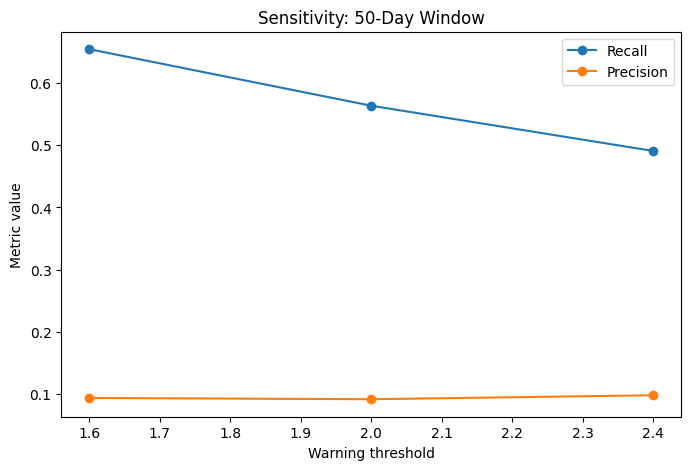

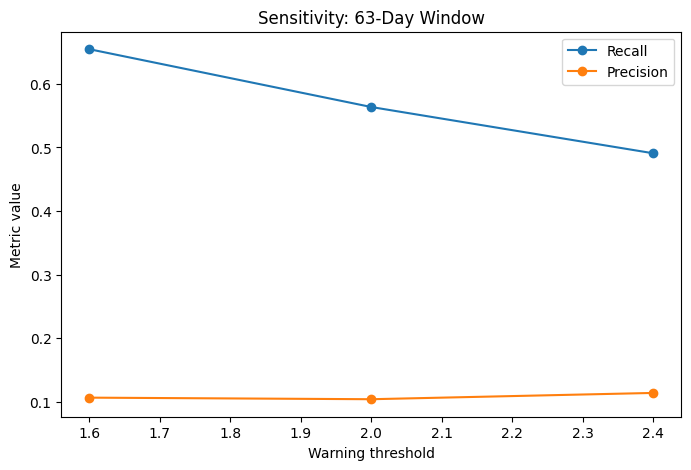

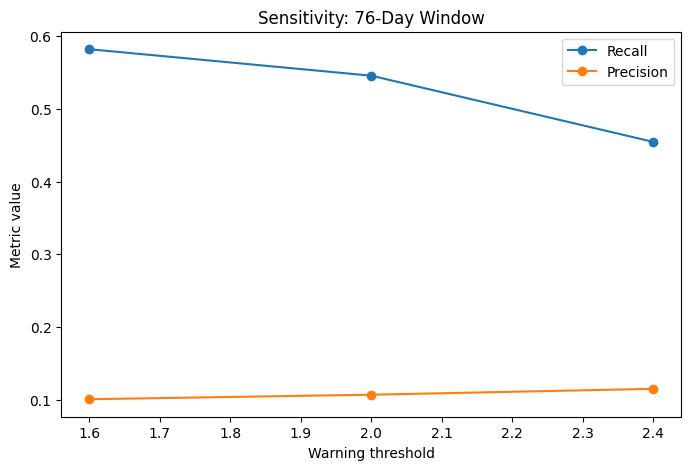

In [25]:
for diagnostic_window in (
    SENSITIVITY_WINDOWS
):
    subset = sensitivity_results.loc[
        sensitivity_results[
            "diagnostic_window"
        ]
        == diagnostic_window
    ]

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        subset["warning_threshold"],
        subset["recall"],
        marker="o",
        label="Recall",
    )

    ax.plot(
        subset["warning_threshold"],
        subset["precision"],
        marker="o",
        label="Precision",
    )

    ax.set_xlabel(
        "Warning threshold"
    )

    ax.set_ylabel(
        "Metric value"
    )

    ax.set_title(
        f"Sensitivity: "
        f"{diagnostic_window}-Day Window"
    )

    ax.legend()
    plt.show()

In [26]:
baseline_report_summary = (
    baseline_comparison[
        [
            "detector",
            "collapse_events",
            "detected_events",
            "warning_events",
            "recall",
            "precision",
            "false_positive_rate",
            "median_lead_time_days",
        ]
    ]
    .copy()
)

baseline_report_summary[
    "common_sample_start"
] = COMMON_EVALUATION_START

baseline_report_summary[
    "common_sample_end"
] = COMMON_EVALUATION_END

baseline_report_summary

,detector,collapse_events,detected_events,warning_events,recall,precision,false_positive_rate,median_lead_time_days,common_sample_start,common_sample_end
0,frozen_excess_kurtosis,55,31,298,0.563636,0.104027,0.895973,83.0,1990-12-31,2026-05-29
1,vix_level_zscore,55,35,540,0.636364,0.064815,0.935185,103.0,1990-12-31,2026-05-29


In [27]:
BASELINE_COMPARISON_OUTPUT = (
    RESULTS
    / "vix_baseline_comparison.csv"
)

FACTOR_BASELINE_OUTPUT = (
    RESULTS
    / "vix_factor_comparison.csv"
)

EVENT_OVERLAP_OUTPUT = (
    RESULTS
    / "vix_event_detection_overlap.csv"
)

OVERLAP_SUMMARY_OUTPUT = (
    RESULTS
    / "vix_overlap_summary.csv"
)

VIX_UNIQUE_WARNING_OUTPUT = (
    RESULTS
    / "vix_unique_warning_summary.csv"
)

SENSITIVITY_OUTPUT = (
    RESULTS
    / "detector_sensitivity_results.csv"
)

COMMON_FROZEN_EVENTS_OUTPUT = (
    RESULTS
    / "common_sample_kurtosis_events.csv"
)

VIX_EVENTS_OUTPUT = (
    RESULTS
    / "common_sample_vix_events.csv"
)

baseline_report_summary.to_csv(
    BASELINE_COMPARISON_OUTPUT,
    index=False,
)

factor_baseline_comparison.to_csv(
    FACTOR_BASELINE_OUTPUT,
    index=False,
)

event_detector_comparison.to_csv(
    EVENT_OVERLAP_OUTPUT,
    index=False,
)

overlap_summary.to_csv(
    OVERLAP_SUMMARY_OUTPUT,
    index=False,
)

vix_unique_warning_summary.to_csv(
    VIX_UNIQUE_WARNING_OUTPUT,
    index=False,
)

sensitivity_results.to_csv(
    SENSITIVITY_OUTPUT,
    index=False,
)

common_frozen_event_results.to_csv(
    COMMON_FROZEN_EVENTS_OUTPUT,
    index=False,
)

vix_event_results.to_csv(
    VIX_EVENTS_OUTPUT,
    index=False,
)

print("✓ Notebook 6 outputs saved")

✓ Notebook 6 outputs saved


In [28]:
def normalize_for_csv(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    output = (
        dataframe
        .copy()
        .reset_index(drop=True)
    )

    output.columns.name = None

    for column in output.columns:
        if pd.api.types.is_datetime64_any_dtype(
            output[column]
        ):
            output[column] = pd.to_datetime(
                output[column],
                errors="coerce",
            )

    for column in output.select_dtypes(
        include=["number"]
    ).columns:
        output[column] = pd.to_numeric(
            output[column],
            errors="coerce",
        ).astype(float)

    return output

def verify_csv_roundtrip(
    original: pd.DataFrame,
    path: Path,
    parse_dates: list[str] | None = None,
) -> None:
    reloaded = pd.read_csv(
        path,
        parse_dates=parse_dates,
    )

    original_normalized = normalize_for_csv(
        original
    )

    reloaded_normalized = normalize_for_csv(
        reloaded
    )

    assert (
        original_normalized.columns.tolist()
        == reloaded_normalized.columns.tolist()
    )

    pd.testing.assert_frame_equal(
        original_normalized,
        reloaded_normalized,
        check_dtype=False,
        check_exact=False,
        check_names=False,
        rtol=1e-9,
        atol=1e-12,
    )

    print("✓", path.name)

verify_csv_roundtrip(
    baseline_report_summary,
    BASELINE_COMPARISON_OUTPUT,
    parse_dates=[
        "common_sample_start",
        "common_sample_end",
    ],
)

verify_csv_roundtrip(
    factor_baseline_comparison,
    FACTOR_BASELINE_OUTPUT,
)

verify_csv_roundtrip(
    event_detector_comparison,
    EVENT_OVERLAP_OUTPUT,
    parse_dates=[
        "collapse_start",
    ],
)

verify_csv_roundtrip(
    overlap_summary,
    OVERLAP_SUMMARY_OUTPUT,
)

verify_csv_roundtrip(
    vix_unique_warning_summary,
    VIX_UNIQUE_WARNING_OUTPUT,
)

verify_csv_roundtrip(
    sensitivity_results,
    SENSITIVITY_OUTPUT,
)

print("✓ All report tables passed reload verification")

✓ vix_baseline_comparison.csv
✓ vix_factor_comparison.csv
✓ vix_event_detection_overlap.csv
✓ vix_overlap_summary.csv
✓ vix_unique_warning_summary.csv
✓ detector_sensitivity_results.csv
✓ All report tables passed reload verification


In [29]:
print("=" * 72)
print("VIX BASELINE AND ROBUSTNESS ANALYSIS COMPLETE")
print("=" * 72)

print(
    "Common sample:",
    COMMON_EVALUATION_START.date(),
    "to",
    COMMON_EVALUATION_END.date(),
)

print(
    "Common-sample collapse events:",
    len(common_holdout_events),
)

print("\nBaseline comparison:")
display(
    baseline_report_summary
)

print("\nDetection overlap:")
display(
    overlap_summary
)

print("\nSensitivity grid:")
display(
    sensitivity_results[
        [
            "diagnostic_window",
            "warning_threshold",
            "is_frozen_primary",
            "recall",
            "precision",
            "false_positive_rate",
            "median_lead_time_days",
        ]
    ]
)

print("\nSaved outputs:")

for path in [
    BASELINE_COMPARISON_OUTPUT,
    FACTOR_BASELINE_OUTPUT,
    EVENT_OVERLAP_OUTPUT,
    OVERLAP_SUMMARY_OUTPUT,
    VIX_UNIQUE_WARNING_OUTPUT,
    SENSITIVITY_OUTPUT,
    COMMON_FROZEN_EVENTS_OUTPUT,
    VIX_EVENTS_OUTPUT,
]:
    print(" -", path.name)

VIX BASELINE AND ROBUSTNESS ANALYSIS COMPLETE
Common sample: 1990-12-31 to 2026-05-29
Common-sample collapse events: 55

Baseline comparison:


,detector,collapse_events,detected_events,warning_events,recall,precision,false_positive_rate,median_lead_time_days,common_sample_start,common_sample_end
0,frozen_excess_kurtosis,55,31,298,0.563636,0.104027,0.895973,83.0,1990-12-31,2026-05-29
1,vix_level_zscore,55,35,540,0.636364,0.064815,0.935185,103.0,1990-12-31,2026-05-29



Detection overlap:


,classification,event_count
0,both,20
1,kurtosis_only,11
2,vix_only,15
3,neither,9



Sensitivity grid:


,diagnostic_window,warning_threshold,is_frozen_primary,recall,precision,false_positive_rate,median_lead_time_days
0,50,1.6,False,0.654545,0.093506,0.906494,82.0
1,50,2.0,False,0.563636,0.091445,0.908555,76.0
2,50,2.4,False,0.490909,0.097826,0.902174,73.0
3,63,1.6,False,0.654545,0.106509,0.893491,89.0
4,63,2.0,True,0.563636,0.104027,0.895973,83.0
5,63,2.4,False,0.490909,0.113924,0.886076,63.0
6,76,1.6,False,0.581818,0.100946,0.899054,83.5
7,76,2.0,False,0.545455,0.107143,0.892857,60.5
8,76,2.4,False,0.454545,0.115207,0.884793,62.0



Saved outputs:
 - vix_baseline_comparison.csv
 - vix_factor_comparison.csv
 - vix_event_detection_overlap.csv
 - vix_overlap_summary.csv
 - vix_unique_warning_summary.csv
 - detector_sensitivity_results.csv
 - common_sample_kurtosis_events.csv
 - common_sample_vix_events.csv
